In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler,LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models ,callbacks

In [ ]:
df=pd.read_csv("/content/Personalized_Diet_Recommendations.csv")

In [ ]:
df

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,...,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,...,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,...,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,...,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,...,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P04996,42,Female,172,99,33.46,NaN,115,78,279,...,59,356,64,Western,Spicy,2869,70,402,68,Low-Carb Diet
4996,P04997,39,Female,155,61,25.39,NaN,110,97,258,...,119,164,112,Indian,NaN,1138,131,213,107,Low-Carb Diet
4997,P04998,48,Female,165,61,22.41,Diabetes,113,82,183,...,50,351,41,Mediterranean,Spicy,2893,40,380,34,Low-Carb Diet
4998,P04999,34,Other,151,82,35.96,Heart Disease,105,75,248,...,50,397,131,Asian,Salty,2201,56,367,128,Low-Fat Diet


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                5000 non-null   object 
 1   Age                       5000 non-null   int64  
 2   Gender                    5000 non-null   object 
 3   Height_cm                 5000 non-null   int64  
 4   Weight_kg                 5000 non-null   int64  
 5   BMI                       5000 non-null   float64
 6   Chronic_Disease           2957 non-null   object 
 7   Blood_Pressure_Systolic   5000 non-null   int64  
 8   Blood_Pressure_Diastolic  5000 non-null   int64  
 9   Cholesterol_Level         5000 non-null   int64  
 10  Blood_Sugar_Level         5000 non-null   int64  
 11  Genetic_Risk_Factor       5000 non-null   object 
 12  Allergies                 1503 non-null   object 
 13  Daily_Steps               5000 non-null   int64  
 14  Exercise

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Chronic_Disease,2043
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Level,0


In [ ]:
df.drop(columns=["Patient_ID"],inplace=True)

In [ ]:
df["Chronic_Disease"]=df["Chronic_Disease"].fillna("No Chronic Disease")

In [ ]:
df.fillna({"Allergies":"No Allergies"},inplace=True)

In [ ]:
df["Food_Aversions"]=df["Food_Aversions"].fillna("No Food_Aversions")

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Chronic_Disease,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Level,0
Blood_Sugar_Level,0


In [ ]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Daily_Steps,Exercise_Frequency,Sleep_Hours,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.805600,174.244000,84.36620,28.353134,133.982400,89.735800,224.297800,159.33020,8458.922800,2.978200,7.019680,2347.350200,124.781800,248.590000,84.522600,2046.236000,129.287000,248.328600,89.029400
std,17.906991,14.229173,20.18103,8.297745,26.216215,17.283025,42.918923,52.14943,3742.408853,2.001431,1.716133,659.880146,43.280037,86.535683,37.495091,671.380142,43.914252,91.152909,38.336083
min,18.000000,150.000000,50.00000,12.630000,90.000000,60.000000,150.000000,70.00000,2004.000000,0.000000,4.000000,1200.000000,50.000000,100.000000,20.000000,725.000000,40.000000,50.000000,10.000000
25%,34.000000,162.000000,67.00000,21.850000,111.000000,75.000000,187.000000,114.00000,5278.750000,1.000000,5.600000,1777.000000,87.000000,175.000000,52.000000,1478.000000,92.000000,173.000000,56.000000
50%,49.000000,174.000000,84.00000,27.640000,133.000000,90.000000,224.000000,160.00000,8452.000000,3.000000,7.000000,2350.500000,126.000000,249.000000,85.000000,2044.000000,129.000000,246.000000,89.000000
75%,64.000000,186.000000,102.00000,33.812500,157.000000,105.000000,261.000000,204.00000,11671.750000,5.000000,8.500000,2921.250000,162.000000,325.000000,116.000000,2621.000000,166.000000,324.000000,121.000000
max,79.000000,199.000000,119.00000,52.890000,179.000000,119.000000,299.000000,249.00000,14997.000000,6.000000,10.000000,3499.000000,199.000000,399.000000,149.000000,3372.000000,218.000000,447.000000,168.000000


#Feature Engineering


In [ ]:
df["Age_BMI"]=df["Age"] * df["BMI"]
df["Weight_Height_Ratio"]=df["Weight_kg"] / df["Height_cm"]
df["Log_Daily_Steps"]=np.log(df["Daily_Steps"])
df["BMI_squared"]=df['BMI']**2

In [ ]:
df.shape

(5000, 33)

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()



In [ ]:
cat_cols

['Gender',
 'Chronic_Disease',
 'Genetic_Risk_Factor',
 'Allergies',
 'Alcohol_Consumption',
 'Smoking_Habit',
 'Dietary_Habits',
 'Preferred_Cuisine',
 'Food_Aversions',
 'Recommended_Meal_Plan']

In [ ]:
encoder=OneHotEncoder()

In [ ]:
encoded=encoder.fit_transform(df[cat_cols])

In [ ]:
encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 50000 stored elements and shape (5000, 34)>

In [ ]:
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(cat_cols))

In [ ]:
encoded_df

,Gender_Female,Gender_Male,Gender_Other,Chronic_Disease_Diabetes,Chronic_Disease_Heart Disease,Chronic_Disease_Hypertension,Chronic_Disease_No Chronic Disease,Chronic_Disease_Obesity,Genetic_Risk_Factor_No,Genetic_Risk_Factor_Yes,...,Preferred_Cuisine_Mediterranean,Preferred_Cuisine_Western,Food_Aversions_No Food_Aversions,Food_Aversions_Salty,Food_Aversions_Spicy,Food_Aversions_Sweet,Recommended_Meal_Plan_Balanced Diet,Recommended_Meal_Plan_High-Protein Diet,Recommended_Meal_Plan_Low-Carb Diet,Recommended_Meal_Plan_Low-Fat Diet
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4996,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4997,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4998,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_non_categorical = df.drop(columns=cat_cols)
df_encoded = pd.concat([df_non_categorical.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 57 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Age                                      5000 non-null   int64  
 1   Height_cm                                5000 non-null   int64  
 2   Weight_kg                                5000 non-null   int64  
 3   BMI                                      5000 non-null   float64
 4   Blood_Pressure_Systolic                  5000 non-null   int64  
 5   Blood_Pressure_Diastolic                 5000 non-null   int64  
 6   Cholesterol_Level                        5000 non-null   int64  
 7   Blood_Sugar_Level                        5000 non-null   int64  
 8   Daily_Steps                              5000 non-null   int64  
 9   Exercise_Frequency                       5000 non-null   int64  
 10  Sleep_Hours                              5000 no

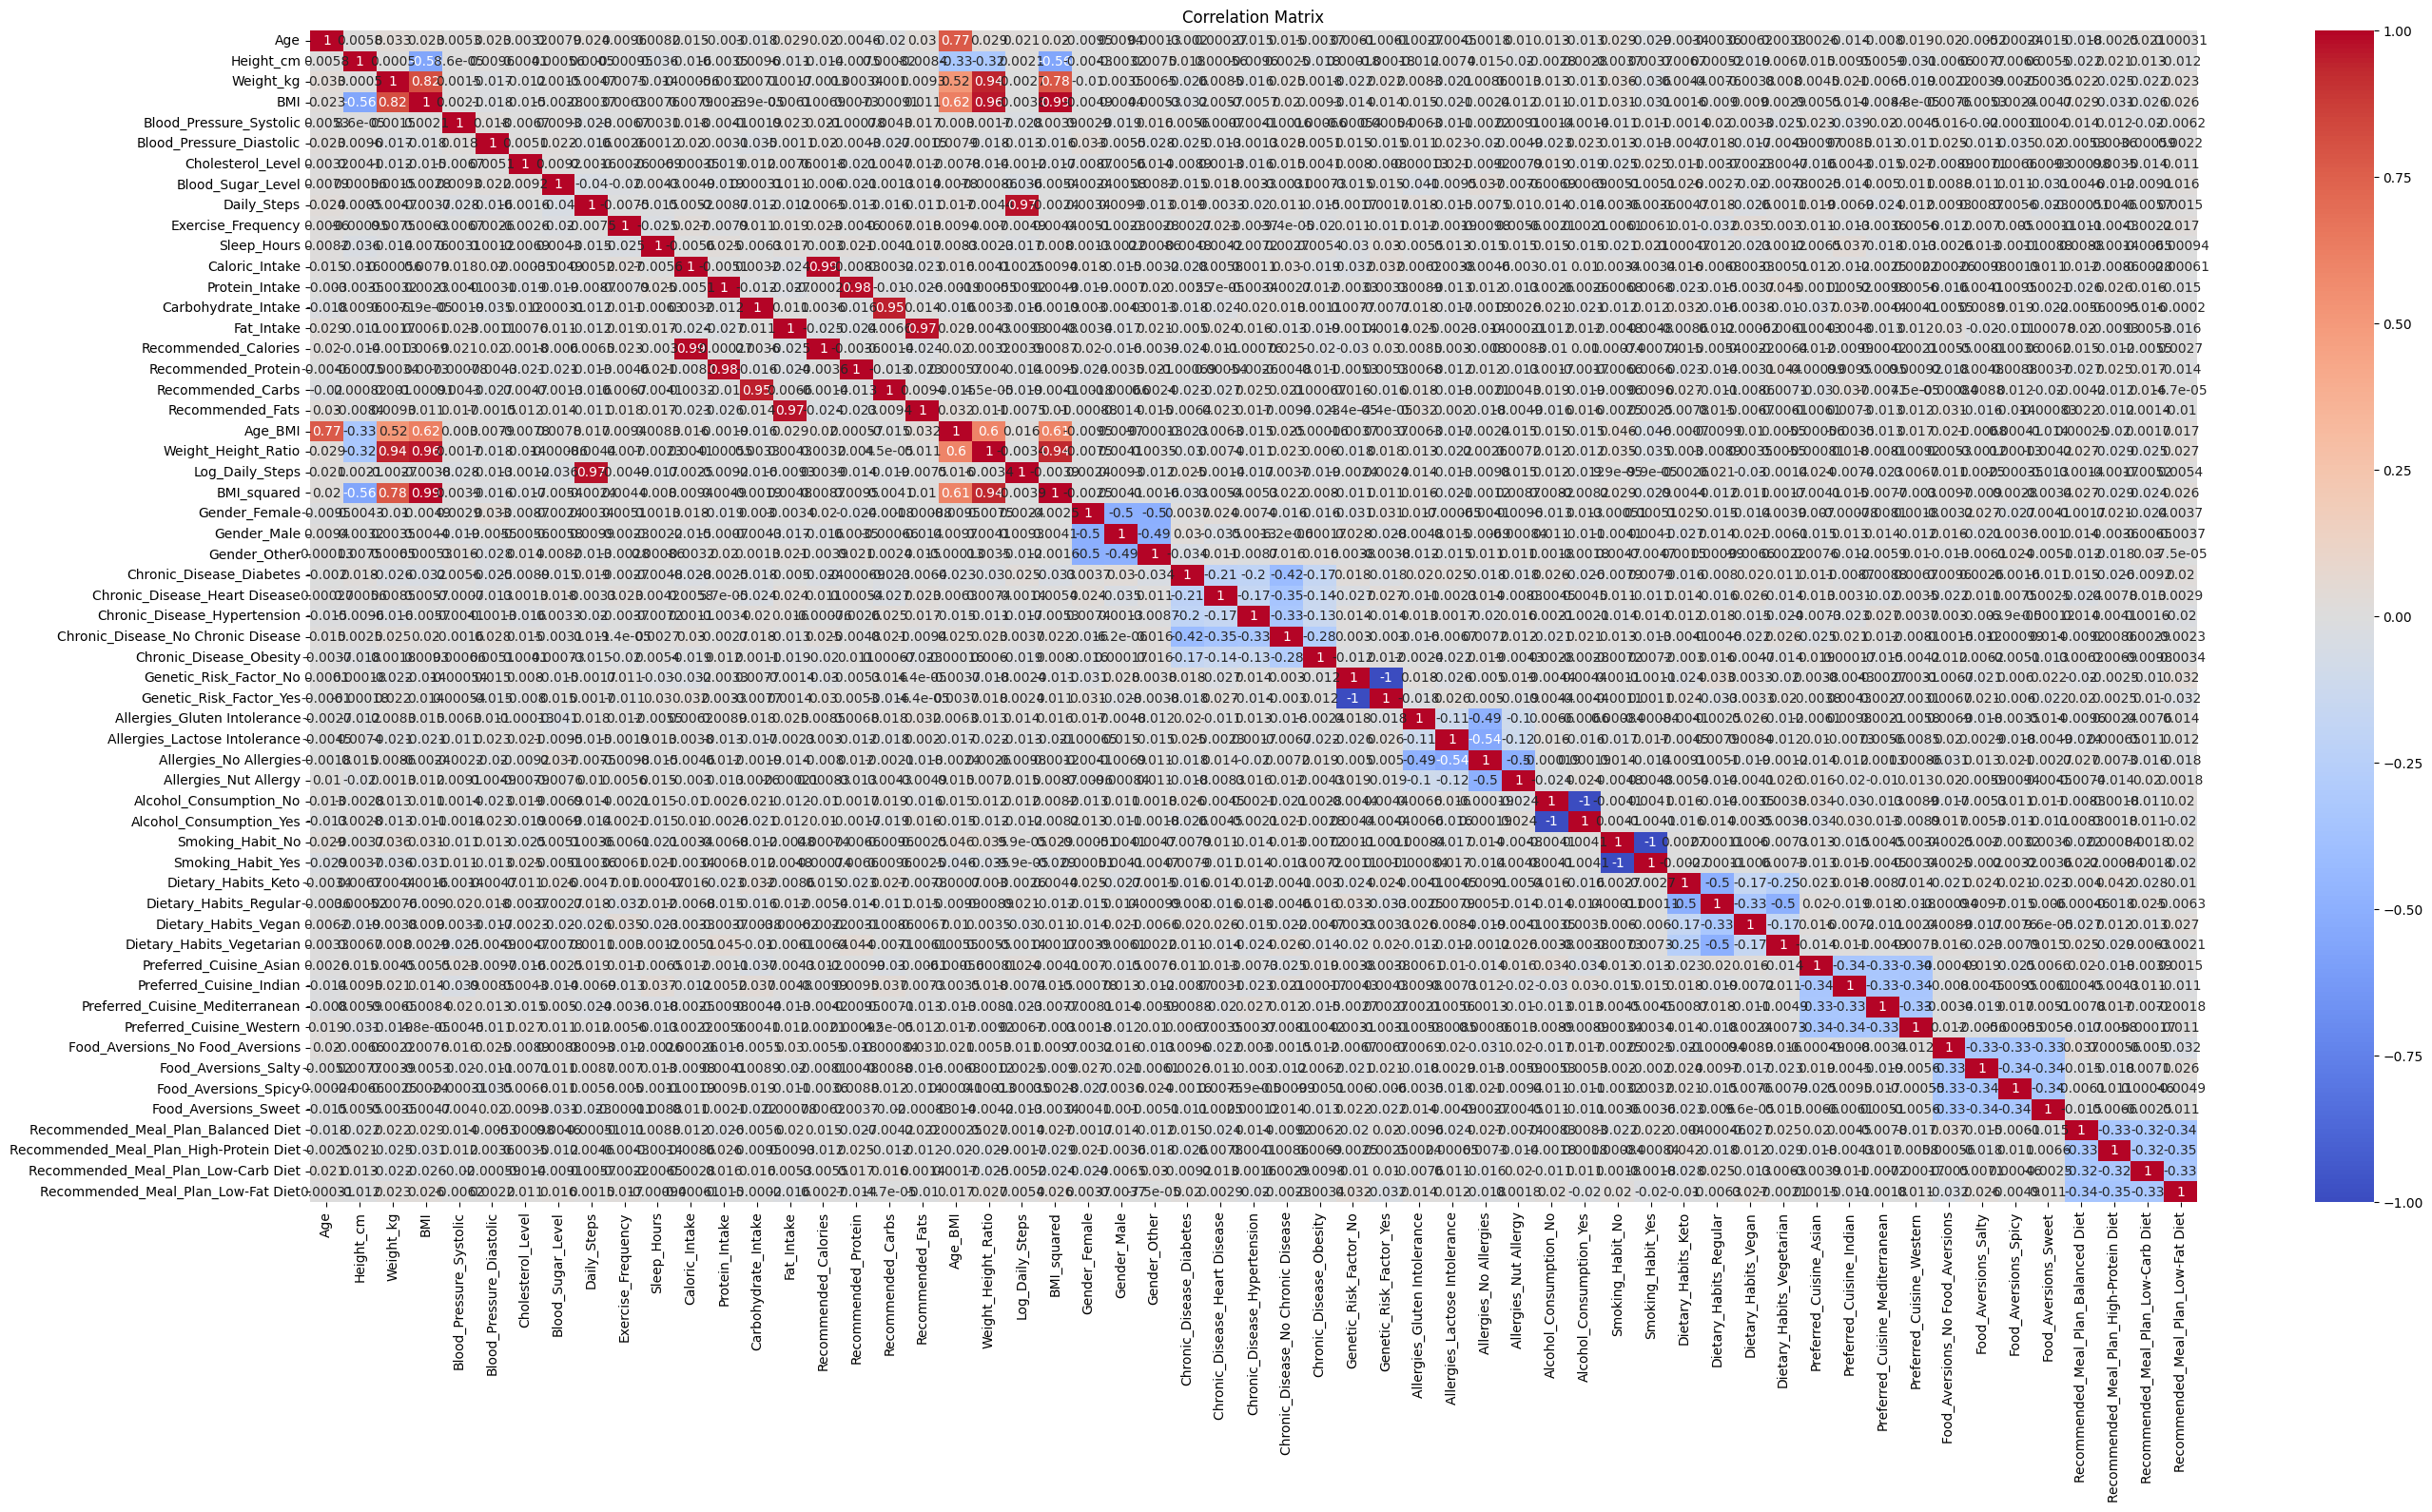

In [ ]:
corr_matrix=df_encoded.corr()
plt.figure(figsize=(32, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_nutri = df_encoded.drop(columns=[
    'Recommended_Meal_Plan_High-Protein Diet',
    'Recommended_Meal_Plan_Low-Carb Diet',
    'Recommended_Meal_Plan_Low-Fat Diet'
])
df_nutri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Age                                  5000 non-null   int64  
 1   Height_cm                            5000 non-null   int64  
 2   Weight_kg                            5000 non-null   int64  
 3   BMI                                  5000 non-null   float64
 4   Blood_Pressure_Systolic              5000 non-null   int64  
 5   Blood_Pressure_Diastolic             5000 non-null   int64  
 6   Cholesterol_Level                    5000 non-null   int64  
 7   Blood_Sugar_Level                    5000 non-null   int64  
 8   Daily_Steps                          5000 non-null   int64  
 9   Exercise_Frequency                   5000 non-null   int64  
 10  Sleep_Hours                          5000 non-null   float64
 11  Caloric_Intake                

In [ ]:
X=df_encoded.drop(columns=["Recommended_Calories","Recommended_Protein","Recommended_Fats","Recommended_Carbs"])
y=df_encoded[["Recommended_Calories","Recommended_Protein","Recommended_Fats","Recommended_Carbs"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,)

### Data Scaling


In [ ]:
# numerical columns for scaling
numerical_cols_X = X_train.select_dtypes(include=np.number).columns
numerical_cols_y = y_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler for X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scale numerical features in X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
y_train_scaled = y_train.copy()
y_test_scaled = y_test.copy()

X_train_scaled[numerical_cols_X] = scaler_X.fit_transform(X_train[numerical_cols_X])
X_test_scaled[numerical_cols_X] = scaler_X.transform(X_test[numerical_cols_X])

# Scale numerical features in y_train and y_test
y_train_scaled[numerical_cols_y] = scaler_y.fit_transform(y_train[numerical_cols_y])
y_test_scaled[numerical_cols_y] = scaler_y.transform(y_test[numerical_cols_y])

print("Numerical features in X and y scaled successfully.")


Numerical features in X and y scaled successfully.


In [ ]:
def build_wellness_model(input_shape):
  model=models.Sequential([
      layers.Dense(128,activation="relu",input_shape=(input_shape,)),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      layers.Dense(64,activation="relu"),
      layers.Dense(32,activation="relu"),

      layers.Dense(4,activation="linear")
  ])
  model.compile(optimizer="adam",loss="mse",metrics=["mae"])
  return model

In [ ]:
#early Stopping
early_stopping=callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20, #wait 10 epochs for improvements
    restore_best_weights=True, #Roll back to the best version of the model
    verbose=1
)

In [ ]:
scaled_model = build_wellness_model(X_train_scaled.shape[1])
scaled_history = scaled_model.fit(X_train_scaled, y_train_scaled,
                                  validation_data=(X_test_scaled, y_test_scaled),
                                  epochs=100,
                                  batch_size=32,
                                  callbacks=[early_stopping],
                                  verbose=1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7945 - mae: 0.7168 - val_loss: 0.4450 - val_mae: 0.5529
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3884 - mae: 0.4970 - val_loss: 0.2202 - val_mae: 0.3791
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2827 - mae: 0.4242 - val_loss: 0.1551 - val_mae: 0.3166
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - mae: 0.3840 - val_loss: 0.1259 - val_mae: 0.2859
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2037 - mae: 0.3602 - val_loss: 0.1107 - val_mae: 0.2685
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1807 - mae: 0.3394 - val_loss: 0.1008 - val_mae: 0.2567
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1664 - mae: 0.3256 - val_loss: 0.0961 - val_mae: 0.2502
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1602 - mae: 0.3192 - val_loss: 0.0899 - val_mae: 0.2424
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss:

In [ ]:
scaled_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,166 (207.68 KB)

 Trainable params: 17,636 (68.89 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 35,274 (137.79 KB)

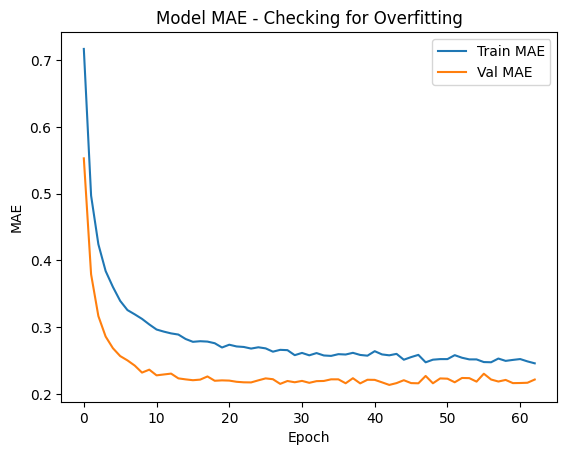

In [ ]:
plt.plot(scaled_history.history['mae'], label='Train MAE')
plt.plot(scaled_history.history['val_mae'], label='Val MAE')
plt.title('Model MAE - Checking for Overfitting')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

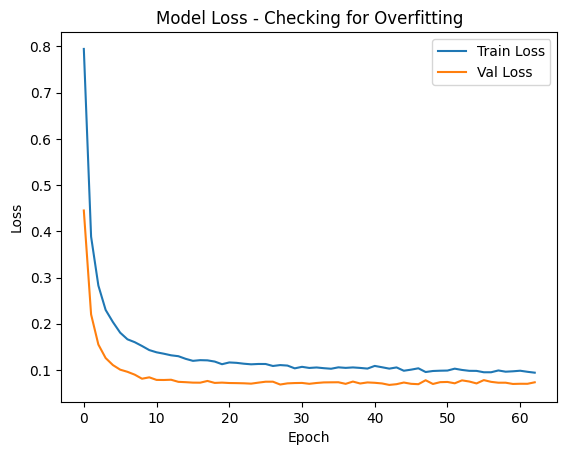

In [ ]:
plt.plot(scaled_history.history['loss'], label='Train Loss')
plt.plot(scaled_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss - Checking for Overfitting')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# predictions on the scaled test data
y_pred_scaled = scaled_model.predict(X_test_scaled)

# MAE for each output
mae_scores = [mean_absolute_error(y_test_scaled.iloc[:, i], y_pred_scaled[:, i]) for i in range(y_test_scaled.shape[1])]

# MSE for each output
mse_scores = [mean_squared_error(y_test_scaled.iloc[:, i], y_pred_scaled[:, i]) for i in range(y_test_scaled.shape[1])]

output_names = y.columns

print("Prediction Scores (Scaled Data):")
for i, name in enumerate(output_names):
    print(f"  {name}: MAE = {mae_scores[i]:.4f}, MSE = {mse_scores[i]:.4f}")

# overall MAE and MSE for all outputs
overall_mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
overall_mse = mean_squared_error(y_test_scaled, y_pred_scaled)

print(f"\nOverall MAE (all outputs): {overall_mae:.4f}")
print(f"Overall MSE (all outputs): {overall_mse:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Prediction Scores (Scaled Data):
  Recommended_Calories: MAE = 0.1683, MSE = 0.0407
  Recommended_Protein: MAE = 0.1853, MSE = 0.0496
  Recommended_Fats: MAE = 0.2083, MSE = 0.0625
  Recommended_Carbs: MAE = 0.2919, MSE = 0.1182

Overall MAE (all outputs): 0.2135
Overall MSE (all outputs): 0.0677


In [ ]:
y_pred_scaled

array([[ 1.2955534 ,  1.5042149 ,  0.5212701 , -0.46503592],
       [-1.296231  , -1.4769083 ,  0.01931519, -0.8872711 ],
       [-0.2211403 ,  1.0462892 ,  1.2276725 , -1.0655302 ],
       ...,
       [ 0.81834   ,  0.70195043,  0.7158032 ,  0.91112787],
       [ 1.0681891 , -0.96172184, -1.1835803 , -0.7528866 ],
       [-0.9989619 , -1.024487  ,  0.48161292,  1.1239682 ]],
      dtype=float32)

In [ ]:
output_names

Index(['Recommended_Calories', 'Recommended_Protein', 'Recommended_Fats',
       'Recommended_Carbs'],
      dtype='object')

In [ ]:
sample_patient_index = X_test.index[0] # Get the original index of the first test sample
sample_patient_data_unscaled = X_test.loc[[sample_patient_index]]


In [ ]:
# Select the corresponding scaled data for prediction
sample_patient_data_scaled = X_test_scaled.loc[[sample_patient_index]]

In [ ]:
# Make a prediction with the scaled model
scaled_prediction = scaled_model.predict(sample_patient_data_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [ ]:
# For the 'prediction_score' in generate_diet_plan
prediction_score_for_risk = scaled_prediction[0, 0]


In [ ]:
# Create a user_data string from relevant unscaled features
patient_age = sample_patient_data_unscaled['Age'].values[0]
patient_gender = df.loc[sample_patient_index, 'Gender']
patient_bmi = sample_patient_data_unscaled['BMI'].values[0]
patient_chronic_disease = df.loc[sample_patient_index, 'Chronic_Disease']


In [ ]:

user_data_string = (
    f"Age {patient_age}, Gender {patient_gender}, BMI {patient_bmi:.2f}, "
    f"Chronic Disease: {patient_chronic_disease}"
)
print(f"Generated patient profile for prompt: {user_data_string}")
print(f"Prediction score for risk (scaled Recommended_Calories): {prediction_score_for_risk:.4f}")

Generated patient profile for prompt: Age 19, Gender Male, BMI 21.22, Chronic Disease: No Chronic Disease
Prediction score for risk (scaled Recommended_Calories): 1.2956


In [ ]:
scaled_prediction_array = np.zeros(y_train_scaled.shape[1])

# Assuming 'Recommended_Calories' is the first column (index 0)
scaled_prediction_array[0] = prediction_score_for_risk

# Reshape for inverse_transform (it expects a 2D array: n_samples, n_features)
unscaled_prediction = scaler_y.inverse_transform(scaled_prediction_array.reshape(1, -1))

# Extract the unscaled Recommended_Calories
unscaled_recommended_calories = unscaled_prediction[0, 0]

print(f"Unscaled Recommended Calories: {unscaled_prediction[0, 0]:.2f} kilocalories")
print(f"Unscaled Recommended Protein: {unscaled_prediction[0, 1]:.2f} grams")
print(f"Unscaled Recommended Fats: {unscaled_prediction[0, 2]:.2f} grams")
print(f"Unscaled Recommended Carbs: {unscaled_prediction[0, 3]:.2f} grams")

Unscaled Recommended Calories: 2907.73 kilocalories
Unscaled Recommended Protein: 128.80 grams
Unscaled Recommended Fats: 88.94 grams
Unscaled Recommended Carbs: 249.35 grams


In [ ]:
import joblib
import json

# Save the ANN Brain
scaled_model.save("wellness_model.h5")

# Save the Scalers (Translators)
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

# Save Feature Columns (To ensure the order never changes)
feature_names = X.columns.tolist()
with open("feature_cols.json", "w") as f:
    json.dump(feature_names, f)

print("All artifacts saved successfully!")

All artifacts saved successfully!


In [ ]:
model = tf.keras.models.load_model("wellness_model.h5", compile=False)

In [ ]:
from tensorflow.keras.metrics import MeanSquaredError
model = tf.keras.models.load_model("wellness_model.h5", custom_objects={"mse": MeanSquaredError()})